# Credit Risk Analysis
## Objetivo
Predecir la probabilidad de que un cliente caiga en morosidad grave 
en los próximos 2 años, utilizando variables financieras y demográficas.

## Dataset
- Fuente: Give Me Some Credit — Kaggle
- Tamaño: 150,000 registros
- Variable objetivo: SeriousDlqin2yrs (1 = moroso, 0 = no moroso)

In [2]:
#Importamos librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


In [3]:
#Cargamos la data
df = pd.read_csv('../data/cs-training.csv')
df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
#Inspeccion Inicial:
#registros y columnas
print(df.shape)

#columnas con tipo de datos para identificar nulos tambien
print(df.info())

#Analisis estadistico inicial
df.describe()


(150000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


Se puede identificar que el dataset presenta 150 000 registros y 12 columnas.
Ademas se identifica valores vacios en las columnas MonthlyIncome y NumberOfDependents
Ademas de que en el analisis estadistico se ve que hay personas con 0 edad y de 109 aunque este ultimo quiza sea posible pero muy raramente, lo cual resulta imposible e ilogico ya que un recien nacido no podria sacar un credito, ademas de personas con ingresos mensuales de 0, que banco podria darle credito a una persona que no tiene ingresos.

In [5]:
#Identificamos nulos en MonthlyIncome 
print('Nulos en MonthlyIncome:', df['MonthlyIncome'].isnull().sum())
print('Porcentaje de nulos en MonthlyIncome en base al total:',df['MonthlyIncome'].isnull().sum()/len(df)*100)

#Identificamos nulos en NumberOfDependents 
print('Nulos en NumberOfDependents:',df['NumberOfDependents'].isnull().sum())
print('Porcentaje de nulos en NumberOfDependents en base al total:',df['NumberOfDependents'].isnull().sum()/len(df)*100)

Nulos en MonthlyIncome: 29731
Porcentaje de nulos en MonthlyIncome en base al total: 19.820666666666668
Nulos en NumberOfDependents: 3924
Porcentaje de nulos en NumberOfDependents en base al total: 2.616


In [6]:
#Vamos a verificar si la media y la mediana de monthlyincome es muy diferente
print('==MonthlyIncome==')
print('Media:',df['MonthlyIncome'].mean())
print('Mediana:',df['MonthlyIncome'].median())

print('\n==NumberOfDependents==')
print('Media', df['NumberOfDependents'].mean())
print('Mediana', df['NumberOfDependents'].median())

==MonthlyIncome==
Media: 6670.221237392844
Mediana: 5400.0

==NumberOfDependents==
Media 0.7572222678605657
Mediana 0.0


In [7]:
#Imputamos los nulos, es decir reemplazamos los nulos por un valor
df['MonthlyIncome'] = df['MonthlyIncome'].fillna(df['MonthlyIncome'].median())
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(df['NumberOfDependents'].median())

In [8]:
print(df.isnull().sum())

Unnamed: 0                              0
SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64


In [9]:
#Vamos a eliminar la columna Unnamed: 0 
df=df.drop(columns='Unnamed: 0')


In [10]:
print(df.shape)

(150000, 11)


In [11]:
print(df['age'].describe())

count    150000.000000
mean         52.295207
std          14.771866
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64


In [12]:
print('Edad <18: ', (df['age']<18).sum())
print('Edad >100: ', (df['age']>100).sum())

Edad <18:  1
Edad >100:  13


In [13]:
#Eliminamos los registros con edades menores a 18 y mayores a 100

df = df[(df['age']>=18) & (df['age']<=100)]

In [14]:
print(df.shape)

(149986, 11)


## Decisiones de limpieza

- **Nulos en MonthlyIncome (19.8%):** Imputados con mediana ($5,400) 
  por distribución sesgada hacia la derecha.
- **Nulos en NumberOfDependents (2.6%):** Imputados con mediana (0) 
  por ser el valor más frecuente.
- **Columna Unnamed: 0:** Eliminada por ser índice sin valor analítico.
- **Registros con edad < 18 o > 100:** 14 filas eliminadas por ser 
  imposibles en contexto de crédito bancario.

In [15]:
#Vamos analizar la variable SeriousDlqin2yrs

print('Cantidad de valores: ', df['SeriousDlqin2yrs'].value_counts())
print('\nQue tanto representa cada valor del total: ', df['SeriousDlqin2yrs'].value_counts(normalize=True)*100)

Cantidad de valores:  SeriousDlqin2yrs
0    139961
1     10025
Name: count, dtype: int64

Que tanto representa cada valor del total:  SeriousDlqin2yrs
0    93.316043
1     6.683957
Name: proportion, dtype: float64


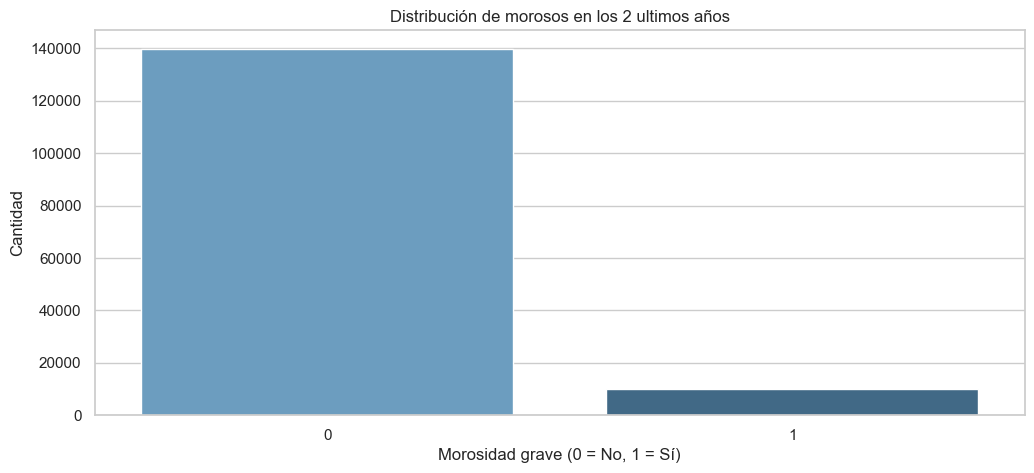

In [16]:
#vamos a crear un grafico de barras

clase = df['SeriousDlqin2yrs'].value_counts().reset_index()
clase.columns = ['Clase','Cantidad']

plt.figure(figsize=(12,5))

sns.barplot(data=clase, x='Clase', y ='Cantidad', hue='Clase', palette='Blues_d', legend=False)
plt.title('Distribución de morosos en los 2 ultimos años')
plt.xlabel('Morosidad grave (0 = No, 1 = Sí)')
plt.ylabel('Cantidad')
plt.show()

## Análisis de la variable objetivo

- Clase 0 (no moroso): 139,961 clientes — 93.3%
- Clase 1 (moroso): 10,025 clientes — 6.7%

El dataset presenta clase desbalanceada. Un modelo que prediga siempre 
"no moroso" tendría 93.3% de accuracy pero sería inútil para el banco 
ya que no detectaría ningún cliente en riesgo real.

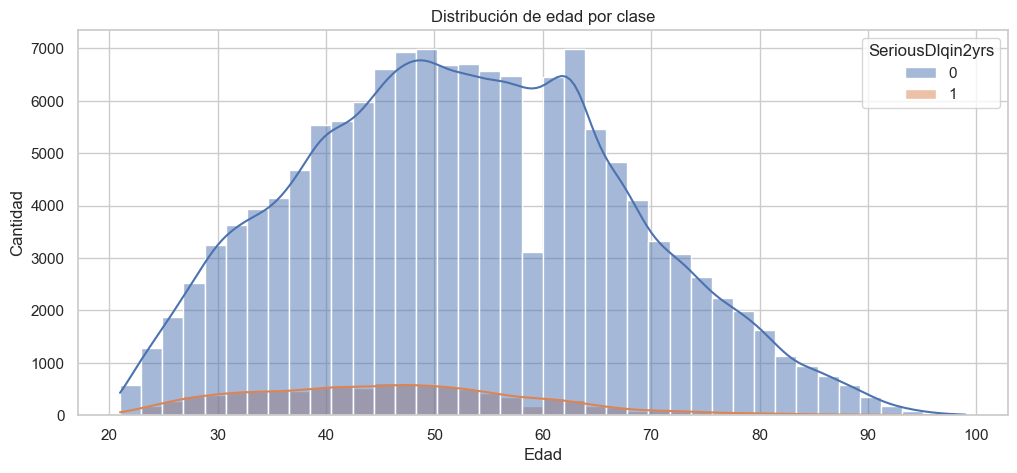

In [17]:
#Vamos analizar la variable edad o age

plt.figure(figsize=(12,5))

sns.histplot(data=df, x='age', hue='SeriousDlqin2yrs', bins = 40, kde=True, alpha=0.5)
plt.title('Distribución de edad por clase')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.show()

In [18]:
#Vamos a calcular la edad promedio de cada grupo
print(df.groupby(by='SeriousDlqin2yrs')['age'].mean())

SeriousDlqin2yrs
0    52.747365
1    45.921097
Name: age, dtype: float64


## Hallazgo: Edad y morosidad

- Edad promedio morosos: 45.9 años
- Edad promedio no morosos: 52.7 años
- Los clientes más jóvenes presentan mayor tendencia a caer en morosidad grave.
- La diferencia de ~7 años sugiere que la edad es una variable relevante para el modelo predictivo.

In [19]:
print(df['DebtRatio'].describe())

count    149986.000000
mean        353.002995
std        2037.902441
min           0.000000
25%           0.175075
50%           0.366503
75%           0.868100
max      329664.000000
Name: DebtRatio, dtype: float64


In [20]:
print('DebtRatio > 1:', (df['DebtRatio'] > 1).sum())
print('DebtRatio > 10:', (df['DebtRatio'] > 10).sum())
print('DebtRatio > 100:', (df['DebtRatio'] > 100).sum())

DebtRatio > 1: 35130
DebtRatio > 10: 28872
DebtRatio > 100: 24376


In [21]:
print('Percentil 95:', df['DebtRatio'].quantile(0.95))
print('Percentil 99:', df['DebtRatio'].quantile(0.99))

Percentil 95: 2449.0
Percentil 99: 4979.599999999977


In [22]:
cap_debtratio = 10
df['DebtRatio'] = df['DebtRatio'].clip(upper=cap_debtratio)

In [23]:
print(df['DebtRatio'].describe())

count    149986.000000
mean          2.263115
std           3.835251
min           0.000000
25%           0.175075
50%           0.366503
75%           0.868100
max          10.000000
Name: DebtRatio, dtype: float64


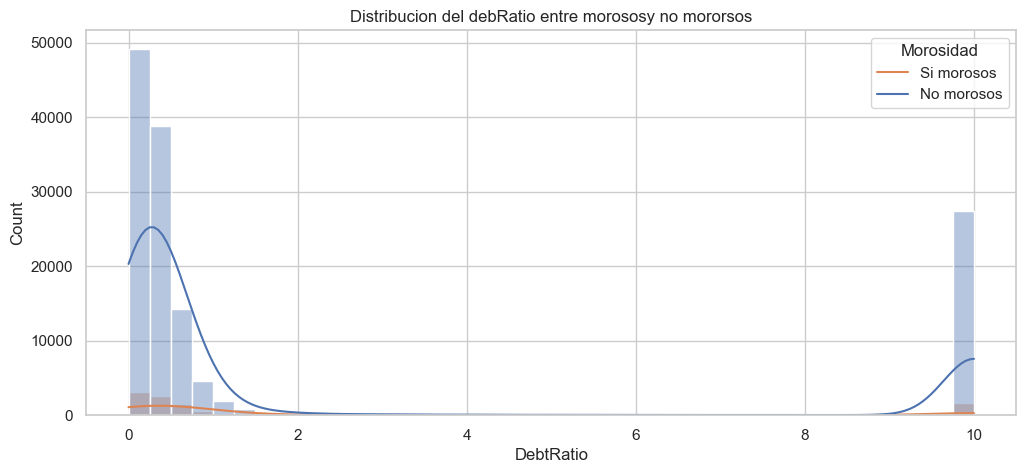

In [24]:
#graficar la distribución de DebtRatio entre morosos y no morosos

plt.figure(figsize=(12,5))

sns.histplot(data=df, x='DebtRatio', hue='SeriousDlqin2yrs', bins=40, kde=True, alpha=0.4)
plt.title('Distribucion del debRatio entre morososy no mororsos')
plt.legend(title='Morosidad', labels=['Si morosos','No morosos'])
plt.show()

In [25]:
#Calcula el DebtRatio promedio de morosos vs no morosos

df.groupby(by='SeriousDlqin2yrs')['DebtRatio'].mean()

SeriousDlqin2yrs
0    2.281712
1    2.003476
Name: DebtRatio, dtype: float64

## Hallazgo: DebtRatio y morosidad

- DebtRatio promedio no morosos: 2.28
- DebtRatio promedio morosos: 2.00
- Contrario a la hipótesis inicial, los morosos no tienen mayor DebtRatio promedio.
- DebtRatio por sí solo no es un predictor fuerte — su poder predictivo 
  puede aumentar en combinación con MonthlyIncome y historial de pagos.

In [26]:
print(df['MonthlyIncome'].describe())

count    1.499860e+05
mean     6.418676e+03
std      1.289096e+04
min      0.000000e+00
25%      3.903250e+03
50%      5.400000e+03
75%      7.400000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64


In [27]:
print('Percentil 95:',df['MonthlyIncome'].quantile(0.95))
print('Percentil 99:',df['MonthlyIncome'].quantile(0.99))

Percentil 95: 13500.0
Percentil 99: 23000.0


In [28]:
cap_income=df['MonthlyIncome'].quantile(0.99)
df['MonthlyIncome']=df['MonthlyIncome'].clip(upper=cap_income)

In [29]:
print(df['MonthlyIncome'].describe())

count    149986.000000
mean       6142.640846
std        3835.763455
min           0.000000
25%        3903.250000
50%        5400.000000
75%        7400.000000
max       23000.000000
Name: MonthlyIncome, dtype: float64


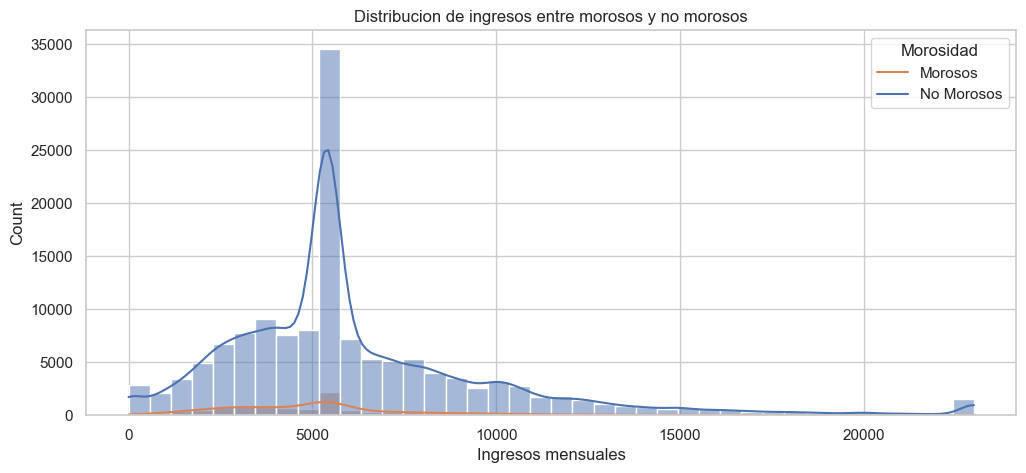

In [30]:
#grafica la distribución de MonthlyIncome entre morosos y no morosos

plt.figure(figsize=(12,5))

sns.histplot(data=df, x='MonthlyIncome', hue='SeriousDlqin2yrs', bins=40, kde=True)
plt.title('Distribucion de ingresos entre morosos y no morosos')
plt.xlabel('Ingresos mensuales')
plt.legend(title='Morosidad',labels=['Morosos', 'No Morosos'])
plt.show()

In [31]:
#ingreso promedio de cada grupo

df.groupby(by='SeriousDlqin2yrs')['MonthlyIncome'].mean()

SeriousDlqin2yrs
0    6193.747851
1    5429.125885
Name: MonthlyIncome, dtype: float64

## Hallazgo: MonthlyIncome y morosidad

- Ingreso promedio no morosos: $6,194
- Ingreso promedio morosos: $5,429
- Los clientes morosos ganan $765 menos en promedio.
- Menor ingreso reduce la capacidad de pago y aumenta el riesgo crediticio.
- MonthlyIncome es una variable relevante para el modelo predictivo.

In [34]:
#Calcula el promedio de cada una por grupo
df.groupby(by='SeriousDlqin2yrs')[['NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate']].mean().reset_index()

,SeriousDlqin2yrs,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
0,0,0.280128,0.126678,0.135238
1,1,2.388529,1.828229,2.091571


## Hallazgo: Historial de pagos tardíos

- Los morosos tienen ~8x más atrasos en todas las categorías.
- Los atrasos de 30-59 días son los más frecuentes en clientes morosos (2.39 promedio).
- El patrón sugiere que la morosidad grave se desarrolla progresivamente
  desde atrasos cortos hacia atrasos prolongados.
- Estas variables son candidatas fuertes como predictores del modelo.

In [ ]:
#un heatmap de correlación entre todas las variables numéricas
plt.figure(figsize=(12,5))

sns.heatmap(data=df, annot=True, fmt='.2f', cmap='coolwarm')
plt.show()